# 02 - Exploratory data analysis
**Questions:** Is demand growing? Is it seasonal (and does that differ by category)? Where is demand? Which SKUs are big and which are volatile? Do promotions matter?

In [1]:
# --- setup: make the project's src/ folder importable and set paths ---
import sys, json
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display, Markdown
import config as cfg
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)
N = json.loads((cfg.TABLES / "key_numbers.json").read_text())   # every number the scripts computed
%matplotlib inline

In [2]:
import kpis, analysis
t = kpis.load_clean()
weekly = kpis.weekly_demand(t)
prod, wh = t["products"], t["warehouses"]
print(weekly.shape, "-> one row per SKU per week")
display(weekly.head())

(9360, 8) -> one row per SKU per week


,sku,week_idx,units_demanded,units_fulfilled,promo_days_n,promo_flag,week_start,month
0,SKU-00001,0,240,240,0,0,2024-01-01,1
1,SKU-00001,1,259,259,0,0,2024-01-08,1
2,SKU-00001,2,288,288,0,0,2024-01-15,1
3,SKU-00001,3,235,235,0,0,2024-01-22,1
4,SKU-00001,4,273,189,0,0,2024-01-29,1


## Trend
Weekly total demand plus a 4-week moving average (smooths the noise so the direction is visible).

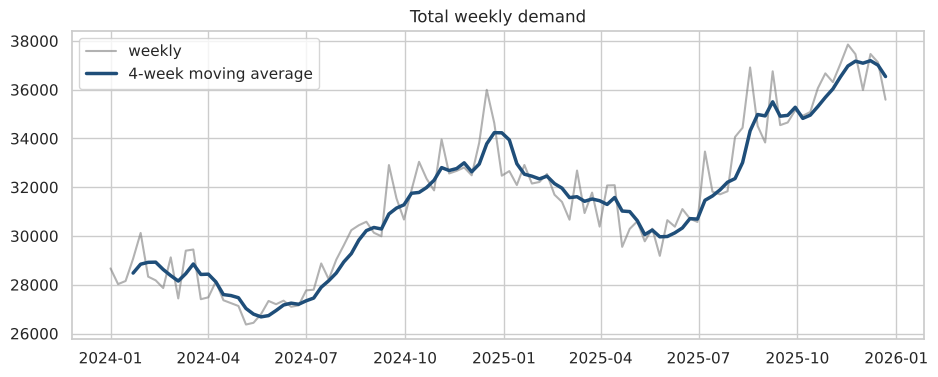

**Year 2 vs year 1:** +12.0%.  **Straight-line trend:** +13.6% per year.

In [3]:
total = weekly.groupby("week_start")["units_demanded"].sum()
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(total.index, total.values, color="grey", alpha=.6, label="weekly")
ax.plot(total.index, total.rolling(4).mean(), color="#1f4e79", lw=2.5, label="4-week moving average")
ax.set_title("Total weekly demand"); ax.legend(); plt.show()
growth = total.iloc[52:].sum() / total.iloc[:52].sum() - 1
slope = analysis.weekly_trend_pct_per_year(total.values)
display(Markdown(f"**Year 2 vs year 1:** {growth:+.1%}.  **Straight-line trend:** {slope:+.1%} per year."))

In [4]:
display(analysis.category_trends(weekly, prod))

,category,trend_pct_per_year
0,Textiles,0.197758
1,Chemicals,0.181123
2,Electronics,0.144015
3,Machinery Parts,0.109482
4,Raw Materials,0.102119
5,Packaging,0.061595


## Seasonality by category
Index = month demand / the year's average month (1.00 = normal). Different categories peak in different months, so one company-wide seasonal factor would be wrong.

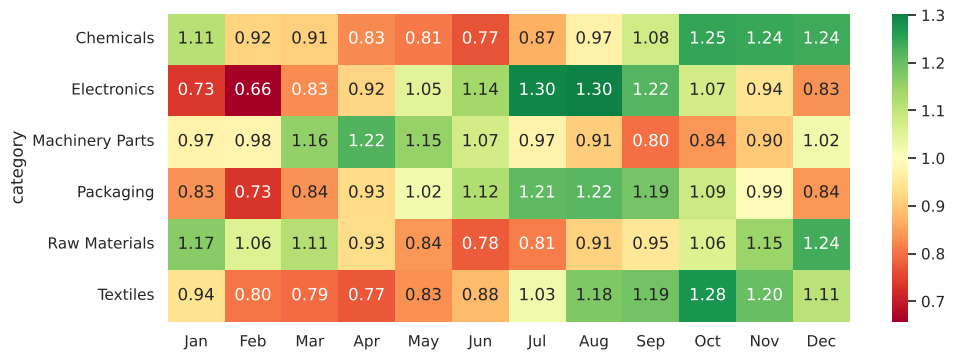

In [5]:
seas = analysis.seasonality_index(t["demand_daily"], prod)
seas.columns = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig, ax = plt.subplots(figsize=(11, 4)); sns.heatmap(seas, annot=True, fmt=".2f", cmap="RdYlGn", center=1, ax=ax); plt.show()

## Region, SKU size and variability

,region,units_demanded,share
0,North America,1491488,0.456764
1,Europe,706282,0.216297
2,Latin America,631396,0.193363
3,East Asia,436172,0.133576


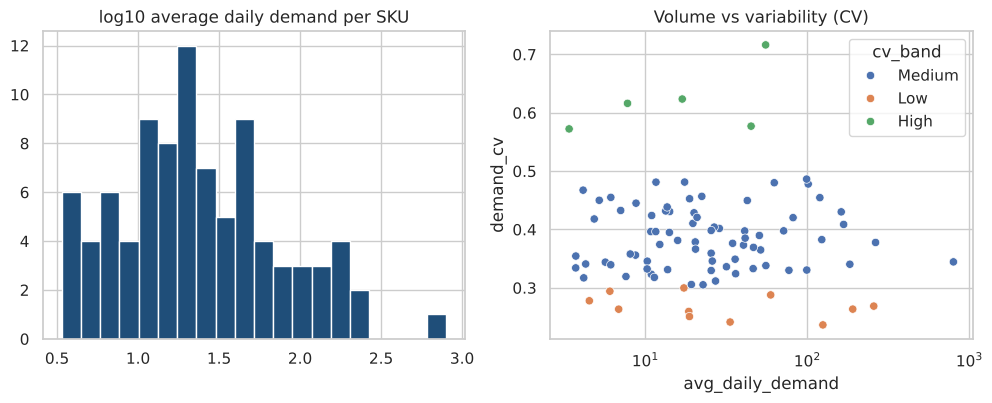

cv_band
Medium    74
Low       11
High       5
Name: count, dtype: int64

In [6]:
display(analysis.region_mix(t["demand_daily"], wh))
sku = kpis.build_sku_kpis(t)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.log10(sku["avg_daily_demand"]), bins=20, color="#1f4e79"); axes[0].set_title("log10 average daily demand per SKU")
sns.scatterplot(data=sku, x="avg_daily_demand", y="demand_cv", hue="cv_band", ax=axes[1]); axes[1].set_xscale("log"); axes[1].set_title("Volume vs variability (CV)")
plt.show()
display(sku["cv_band"].value_counts())

## Promotions

In [7]:
up = analysis.promo_uplift(weekly); display(up)
r = up.set_index("promo_flag")["median_ratio"]

,promo_flag,median_ratio,mean_ratio,n_weeks
0,0,0.978102,0.984447,7659
1,1,1.227525,1.262413,981


In [8]:
display(Markdown(f"""### So what
* Demand grows **{N['eda_yoy_growth_total']:.1%}** year on year, fastest in **{N['eda_fastest_growing_category']}** ({N['eda_fastest_growing_pct']:.1%} per year). A reorder policy fixed at the start becomes too low every month.
* Seasonality differs by category (peaks: {N['eda_seasonality_peak_months']}). **{N['eda_most_seasonal_category']}** swings {N['eda_most_seasonal_swing']:.2f} index points.
* Promo weeks run at **{r.loc[1]:.2f}x** the previous 8-week average vs {r.loc[0]:.2f}x normally - promotions must be in the forecast.
* The biggest SKU sells {N['eda_sku_max_over_min_volume']:.0f}x the smallest, so SKUs must be scaled before modelling and ABC matters.
* **Action:** plan stock by category season and promo calendar, not by a flat yearly parameter."""))

### So what
* Demand grows **12.0%** year on year, fastest in **Textiles** (19.8% per year). A reorder policy fixed at the start becomes too low every month.
* Seasonality differs by category (peaks: Chemicals: Oct; Electronics: Aug; Machinery Parts: Apr; Packaging: Aug; Raw Materials: Dec; Textiles: Oct). **Electronics** swings 0.65 index points.
* Promo weeks run at **1.23x** the previous 8-week average vs 0.98x normally - promotions must be in the forecast.
* The biggest SKU sells 236x the smallest, so SKUs must be scaled before modelling and ABC matters.
* **Action:** plan stock by category season and promo calendar, not by a flat yearly parameter.